In [7]:
# Cell 1 — Paths + imports
import os, json, math, re
from pathlib import Path
from typing import Dict, Any, List, Tuple, Optional

from PIL import Image, ImageDraw, ImageFont

OCR_JSON_DIR = Path("outputs/ocr_json_jap")              # your cleaned OCR JSON per page
PAGES_DIR    = Path("data/jap_imgs")                # original page PNGs
OUT_TJSON_DIR = Path("outputs/translated_json_jap")      # translated JSON per page
OUT_RENDER_DIR = Path("outputs/final_pages_bbox_jap")    # rendered pages

OUT_TJSON_DIR.mkdir(parents=True, exist_ok=True)
OUT_RENDER_DIR.mkdir(parents=True, exist_ok=True)

# Pick a font that exists on your machine (Windows examples below)
FONT_CANDIDATES = [
    r"C:\Windows\Fonts\arial.ttf",
    r"C:\Windows\Fonts\calibri.ttf",
    r"C:\Windows\Fonts\times.ttf",
]
FONT_PATH = next((p for p in FONT_CANDIDATES if os.path.exists(p)), None)
if FONT_PATH is None:
    raise FileNotFoundError("Set FONT_PATH to a valid .ttf on your system.")
print("Using font:", FONT_PATH)

Using font: C:\Windows\Fonts\arial.ttf


In [2]:
# Cell 2 — Load/save helpers + schema helpers (bbox/text/conf)
def load_json(p: Path) -> Any:
    with open(p, "r", encoding="utf-8") as f:
        return json.load(f)

def save_json(obj: Any, p: Path) -> None:
    p.parent.mkdir(parents=True, exist_ok=True)
    with open(p, "w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)
        
def normalize_text(text: Optional[str]) -> str:
    # ✅ None-safe
    if text is None:
        return ""
    text = str(text)

    # basic cleanup (tweak as you like)
    text = text.replace("\u3000", " ")          # full-width space -> space
    text = text.replace("\n", " ").replace("\r", " ")
    text = re.sub(r"\s+", " ", text).strip()
    return text

def get_items(page_obj: Any) -> List[Dict[str, Any]]:
    # Supports either {"items":[...]} or list directly
    if isinstance(page_obj, list):
        return page_obj
    if isinstance(page_obj, dict):
        for k in ["items", "boxes", "bubbles", "ocr"]:
            if k in page_obj and isinstance(page_obj[k], list):
                return page_obj[k]
    raise ValueError("Unrecognized OCR JSON schema")

def get_bbox_xyxy(it: Dict[str, Any]) -> Tuple[int,int,int,int]:
    bb = it.get("bbox_xyxy", it.get("bbox", None))
    if bb is None:
        raise KeyError("Missing bbox_xyxy/bbox")
    x1,y1,x2,y2 = bb
    return int(round(x1)), int(round(y1)), int(round(x2)), int(round(y2))

def get_ja_text(it: Dict[str, Any]) -> str:
    for k in ["ja_text", "text", "ocr_text", "jp_text"]:
        if k in it:
            return normalize_text(it[k])
    return ""

def get_conf(it: Dict[str, Any]) -> Optional[float]:
    for k in ["conf", "avg_conf", "confidence", "ocr_conf"]:
        if k in it:
            try:
                return float(it[k])
            except:
                return None
    return None

In [3]:
USE_MARIAN = True
translator_mode = "placeholder"

MODEL_NAME = "susiexyf/marian-finetuned-ja-en"
tokenizer = None
model = None
device = None

if USE_MARIAN:
    try:
        import torch
        from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

        tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)  # add local_files_only=True if needed
        model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)

        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        model = model.to(device).eval()

        translator_mode = "marian"
        print("✅ MarianMT loaded:", MODEL_NAME, "| device:", device)

    except Exception as e:
        translator_mode = "placeholder"
        tokenizer, model, device = None, None, None
        print("⚠️ MarianMT not available, using placeholder:", repr(e))
        raise Exception(e)


def translate_ja_to_en(text: Optional[str], max_in_len: int = 256) -> str:
    text = normalize_text(text)
    if not text:
        return ""
    if translator_mode == "placeholder" or tokenizer is None or model is None:
        return f"[EN] {text}"

    import torch
    with torch.no_grad():
        batch = tokenizer(
            text,
            return_tensors="pt",
            truncation=True,
            max_length=max_in_len,
        ).to(device)

        gen = model.generate(**batch, max_new_tokens=128)
        out = tokenizer.decode(gen[0], skip_special_tokens=True)

    return normalize_text(out)

C:\Users\abcdj\AppData\Roaming\Python\Python310\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 254/254 [00:00<00:00, 366.00it/s, Materializing param=model.shared.weight]                                  


✅ MarianMT loaded: susiexyf/marian-finetuned-ja-en | device: cpu


In [4]:
# Cell 4 — Translate one page JSON -> translated JSON
def translate_page_json(ocr_json_path: Path) -> Dict[str, Any]:
    obj = load_json(ocr_json_path)
    items = get_items(obj)

    out_items = []
    for it in items:
        ja = get_ja_text(it)
        en = translate_ja_to_en(ja) if ja else ""
        new_it = dict(it)
        new_it["ja_text"] = ja
        new_it["en_text"] = en
        c = get_conf(it)
        if c is not None:
            new_it["conf"] = c
        out_items.append(new_it)

    return {
        "source_ocr_json": str(ocr_json_path),
        "translator": translator_mode,
        "items": out_items
    }

# Example: translate the first OCR JSON
ocr_files = sorted(OCR_JSON_DIR.glob("*.json"))
print("Found OCR JSON:", len(ocr_files))
t0 = translate_page_json(ocr_files[0])
out_path = OUT_TJSON_DIR / ocr_files[0].name
save_json(t0, out_path)
print("✅ Saved:", out_path)

# Show 10 examples (milestone asset)
shown = 0
for it in t0["items"]:
    if it.get("ja_text"):
        print("JA:", it["ja_text"])
        print("EN:", it["en_text"])
        print("----")
        shown += 1
    if shown >= 10:
        break

Found OCR JSON: 6
✅ Saved: outputs\translated_json_jap\pg_1.json
JA: 幾少こ
EN: The number is small.
----
JA: 前1港 年に 程は
EN: In the previous 1 harbor year, krypton was found.
----
JA: し停海 そ泊賊
EN: The sea was closed and the sea was settled down.
----
JA: 何する気だ お
EN: What do they do?
----
JA: 風は乗
EN: Wind is on board.
----
JA: 平い村 和たは である つて -
EN: Hiramura Sumitsu is one of them.
----
JA: Cm!
EN: Cm!
----


In [5]:
# Cell 5 — Text wrapping + fitting inside bbox (PIL)
def text_bbox(draw: ImageDraw.ImageDraw, text: str, font: ImageFont.FreeTypeFont) -> Tuple[int,int]:
    bb = draw.multiline_textbbox((0,0), text, font=font, spacing=2, align="center")
    return (bb[2]-bb[0], bb[3]-bb[1])

def wrap_to_width(draw: ImageDraw.ImageDraw, text: str, font: ImageFont.FreeTypeFont, max_w: int) -> str:
    text = normalize_text(text)
    if not text:
        return ""
    words = text.split(" ")
    if len(words) == 1:
        return text

    lines, cur = [], ""
    for w in words:
        test = (cur + " " + w).strip()
        tw, _ = text_bbox(draw, test, font)
        if tw <= max_w or not cur:
            cur = test
        else:
            lines.append(cur)
            cur = w
    if cur:
        lines.append(cur)
    return "\n".join(lines)

def fit_text(draw: ImageDraw.ImageDraw, text: str, box_w: int, box_h: int,
             max_font: int = 42, min_font: int = 10) -> Dict[str, Any]:
    text = normalize_text(text)
    if not text:
        return {"fits": True, "font_size": None, "wrapped": ""}

    for fs in range(max_font, min_font-1, -1):
        font = ImageFont.truetype(FONT_PATH, fs)
        wrapped = wrap_to_width(draw, text, font, max_w=box_w)
        tw, th = text_bbox(draw, wrapped, font)
        if tw <= box_w and th <= box_h:
            return {"fits": True, "font_size": fs, "wrapped": wrapped, "tw": tw, "th": th}

    # fallback smallest
    fs = min_font
    font = ImageFont.truetype(FONT_PATH, fs)
    wrapped = wrap_to_width(draw, text, font, max_w=box_w)
    tw, th = text_bbox(draw, wrapped, font)
    return {"fits": (tw <= box_w and th <= box_h), "font_size": fs, "wrapped": wrapped, "tw": tw, "th": th}

def draw_centered(draw: ImageDraw.ImageDraw, box: Tuple[int,int,int,int], wrapped: str, font_size: int):
    x1,y1,x2,y2 = box
    font = ImageFont.truetype(FONT_PATH, font_size)
    tw, th = text_bbox(draw, wrapped, font)
    bx, by = x2-x1, y2-y1
    x = x1 + (bx - tw)//2
    y = y1 + (by - th)//2
    draw.multiline_text((x,y), wrapped, font=font, fill=(0,0,0), spacing=2, align="center")

✅ Saved: outputs\final_pages_bbox_jap\pg_1_translated.png


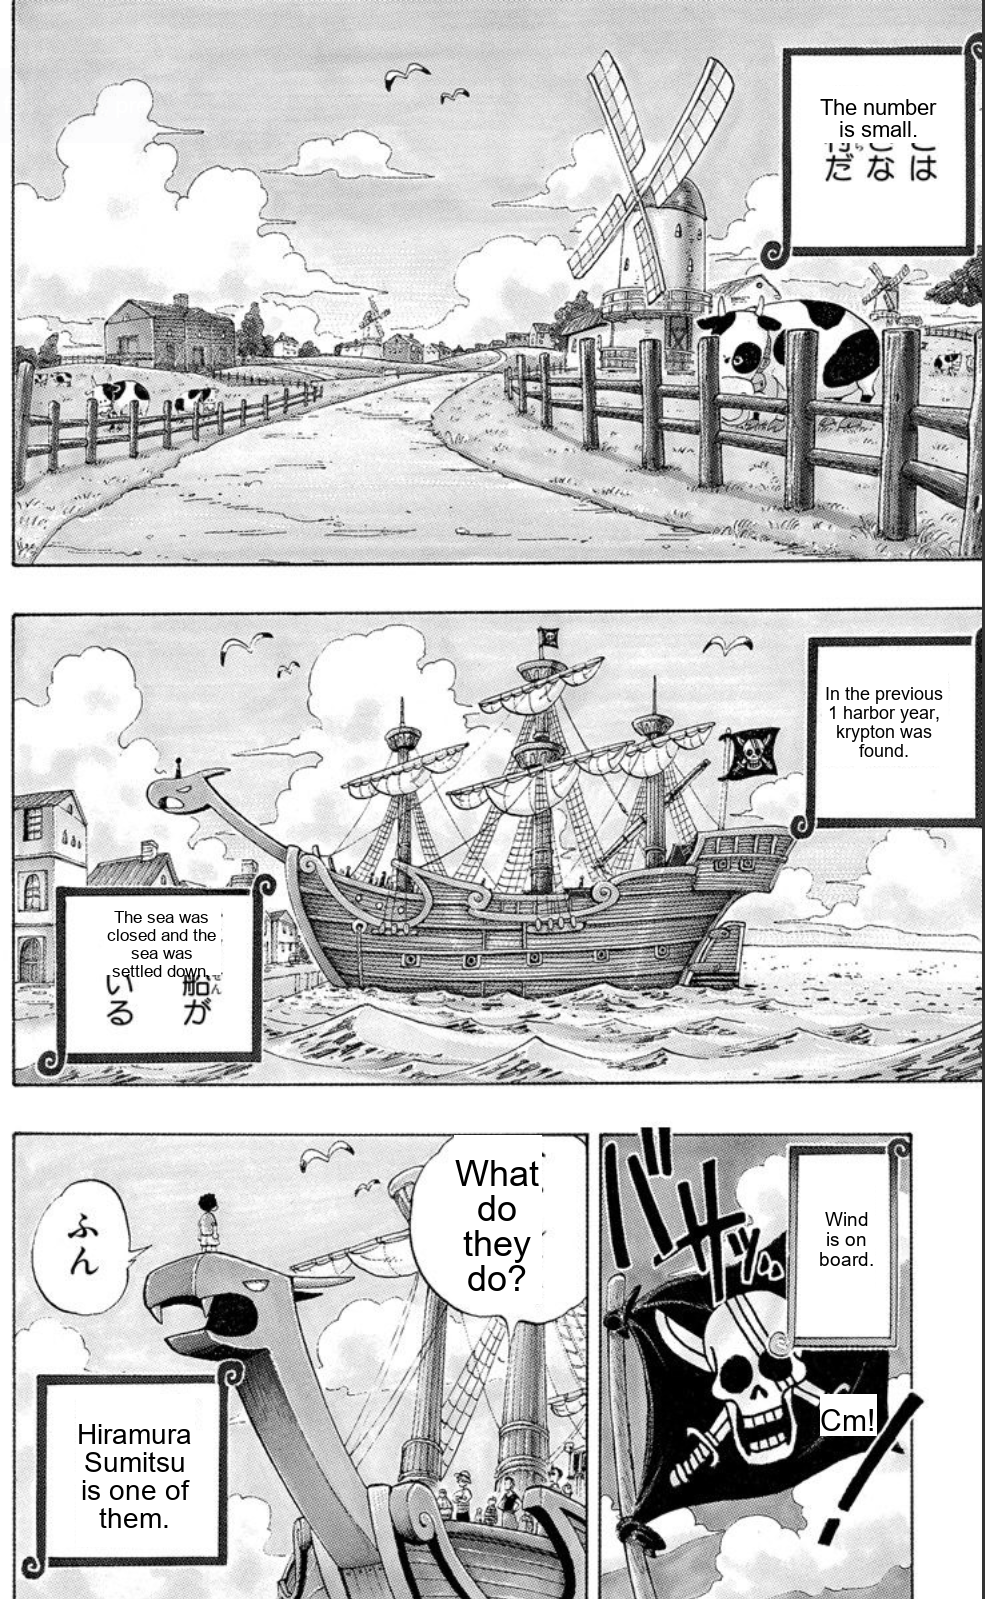

In [8]:
# Cell 6 — Re-render ONE page: whiten bbox + place wrapped English
def render_page_from_translated_json(page_png: Path, translated_json: Path,
                                    pad: int = 2,
                                    max_font: int = 42,
                                    min_font: int = 10) -> Dict[str, Any]:
    page = Image.open(page_png).convert("RGB")
    draw = ImageDraw.Draw(page)

    obj = load_json(translated_json)
    items = get_items(obj) if "items" not in obj else obj["items"]

    debug = []
    for it in items:
        x1,y1,x2,y2 = get_bbox_xyxy(it)
        # pad inward
        x1p,y1p,x2p,y2p = x1+pad, y1+pad, x2-pad, y2-pad
        x1p, y1p = max(0,x1p), max(0,y1p)
        x2p, y2p = min(page.width,x2p), min(page.height,y2p)
        bw, bh = x2p-x1p, y2p-y1p
        if bw < 6 or bh < 6:
            continue

        en = normalize_text(it.get("en_text",""))
        if not en:
            continue

        # 1) remove (baseline): fill bbox white
        draw.rectangle([x1p,y1p,x2p,y2p], fill=(255,255,255))

        # 2) fit + render
        fit = fit_text(draw, en, bw, bh, max_font=max_font, min_font=min_font)
        if fit["wrapped"] and fit["font_size"] is not None:
            draw_centered(draw, (x1p,y1p,x2p,y2p), fit["wrapped"], fit["font_size"])

        debug.append({
            "bbox_xyxy": [x1,y1,x2,y2],
            "pad_bbox_xyxy": [x1p,y1p,x2p,y2p],
            "fits": fit.get("fits"),
            "font_size": fit.get("font_size"),
            "en_len": len(en),
            "ja_len": len(it.get("ja_text","")),
            "conf": it.get("conf", None),
        })

    return {"image": page, "debug": debug}

# Example: render first page using stem-matching
tjson_files = sorted(OUT_TJSON_DIR.glob("*.json"))
tj = tjson_files[0]
stem = tj.stem
page_png = PAGES_DIR / f"{stem}.png"

out = render_page_from_translated_json(page_png, tj, pad=2, max_font=42, min_font=10)
save_path = OUT_RENDER_DIR / f"{stem}_translated.png"
out["image"].save(save_path)
print("✅ Saved:", save_path)

out["image"]  # display

In [9]:
# Cell 7 — Batch translate + batch render all pages
ocr_files = sorted(OCR_JSON_DIR.glob("*.json"))
print("OCR pages:", len(ocr_files))

all_debug = {}

for ocr_path in ocr_files:
    stem = ocr_path.stem
    page_png = PAGES_DIR / f"{stem}.png"
    if not page_png.exists():
        print("⚠️ Missing page image for:", stem)
        continue

    # translate
    t_obj = translate_page_json(ocr_path)
    t_path = OUT_TJSON_DIR / ocr_path.name
    save_json(t_obj, t_path)

    # render
    out = render_page_from_translated_json(page_png, t_path, pad=2, max_font=42, min_font=10)
    out_img_path = OUT_RENDER_DIR / f"{stem}_translated.png"
    out["image"].save(out_img_path)
    all_debug[stem] = out["debug"]

print("✅ Done. Rendered pages:", len(list(OUT_RENDER_DIR.glob("*.png"))))

# Save debug for metrics later
save_json(all_debug, Path("outputs/debug/render_debug_bbox.json"))

OCR pages: 6
✅ Done. Rendered pages: 6


In [10]:
# Cell 8 — Quick metrics table (optional but great for milestone)
import pandas as pd

dbg = load_json(Path("outputs/debug/render_debug_bbox.json"))
rows = []
for page, items in dbg.items():
    n = len(items)
    if n == 0:
        continue
    over = sum(1 for it in items if it.get("fits") is False)
    small = sum(1 for it in items if (it.get("font_size") is not None and it["font_size"] < 12))
    confs = [it["conf"] for it in items if it.get("conf") is not None]
    rows.append({
        "page": page,
        "num_boxes": n,
        "avg_conf": sum(confs)/len(confs) if confs else None,
        "overflowed": over,
        "small_font_lt12": small,
        "avg_font_size": sum([it["font_size"] for it in items if it.get("font_size")]) / max(1, len([it for it in items if it.get("font_size")])),
    })

df = pd.DataFrame(rows).sort_values("page")
df.to_csv("outputs/metrics_bbox.csv", index=False)
df.head(10)

,page,num_boxes,avg_conf,overflowed,small_font_lt12,avg_font_size
0,pg_1,7,0.780415,0,0,24.285714
1,pg_2,11,0.819070,0,1,20.454545
2,pg_3,12,0.859811,0,0,25.250000
3,pg_4,9,0.856801,0,0,28.777778
4,pg_5,8,0.826494,0,0,17.875000
5,pg_6,17,0.822455,2,3,20.764706
